In [6]:
# ===== Cell 1: imports & config =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report

METADATA_PATH = "/kaggle/input/datasets/atheeralboloshi/metadata/Metadata.csv"
CSV_PATH      = "/kaggle/input/datasets/atheeralboloshi/compound2/Compound2.csv"

SEED     = 42
N_SPLITS = 3   # keep <= number of distinct studies; adjust if you have fewer groups

In [7]:
# ===== Cell 2: load + merge (groups = true study/series, not GSM-ID prefix) =====
gene_df = pd.read_csv(CSV_PATH)
id_col = [c for c in gene_df.columns if gene_df[c].astype(str).str.match(r'^GSM\d+$').all()][0]
gene_df = gene_df.rename(columns={id_col: "sample_id"})
gene_df = gene_df.drop(columns=[c for c in gene_df.columns if c.startswith("Unnamed:")])
gene_df = gene_df.drop(columns=[c for c in ["condition", "maturity_label"] if c in gene_df.columns], errors="ignore")

meta   = pd.read_csv(METADATA_PATH)
merged = meta.merge(gene_df, on="sample_id", how="inner", validate="one_to_one")

GENE_COLS = [c for c in gene_df.columns if c != "sample_id"]
counts    = merged[GENE_COLS].values.astype(np.float32)   # raw counts
groups    = merged["series"].to_numpy()                    # study/batch label
condition = merged["condition"].to_numpy()

le      = LabelEncoder()
y       = le.fit_transform(condition)
CLASSES = list(le.classes_)

print("counts:", counts.shape, "| classes:", CLASSES, "| n groups:", len(np.unique(groups)))
print(merged["series"].unique())
print(pd.Series(condition).value_counts())
print(pd.crosstab(merged["series"], condition))

counts: (539, 5000) | classes: ['Adult', 'Embryonic', 'Maturing'] | n groups: 7
['GSE131236' 'GSE117192' 'GTEx' 'GSE122380' 'GSE141910'
 'GSE85331,GSE85332' 'GSE239918']
Embryonic    313
Adult        170
Maturing      56
Name: count, dtype: int64
col_0              Adult  Embryonic  Maturing
series                                       
GSE117192              0          0        44
GSE122380              0        297         0
GSE131236              0          0         4
GSE141910            166          0         0
GSE239918              0          3         3
GSE85331,GSE85332      0         13         5
GTEx                   4          0         0


In [8]:
# ===== Cell 3: normalize — CPM + log1p (library size correction) =====
# Safe to do globally: it's a per-sample transform, uses no label/group info, so no leakage risk here.
# Per-fold StandardScaler (fit on train only) happens inside the CV loop in Cell 4 -- SVM needs
# feature scaling to work properly; RF doesn't strictly need it but scaling doesn't hurt it either.
def cpm_log1p(X):
    lib = X.sum(axis=1, keepdims=True)
    lib[lib == 0] = 1.0
    return np.log1p(X / lib * 1e6).astype(np.float32)

already_transformed = np.nanmax(counts) < 50
X = counts.copy() if already_transformed else cpm_log1p(counts)
print("normalized X:", X.shape, "| max value:", X.max())






# ===== Cell 4: StratifiedGroupKFold — RF + LinearSVM, OOF predictions concatenated =====
sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

rf_importances  = np.zeros((N_SPLITS, X.shape[1]))
svm_coef_abs    = np.zeros((N_SPLITS, X.shape[1]))

oof_true    = np.zeros(len(y), dtype=int)
oof_pred_rf  = np.zeros(len(y), dtype=int)
oof_pred_svm = np.zeros(len(y), dtype=int)

for fold, (train_idx, test_idx) in enumerate(sgkf.split(X, y, groups)):
    X_tr_raw, X_te_raw = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]
    test_groups = np.unique(groups[test_idx])

    # scaler fit on TRAIN fold only -> avoids leaking test-fold statistics
    scaler = StandardScaler().fit(X_tr_raw)
    X_tr = scaler.transform(X_tr_raw)
    X_te = scaler.transform(X_te_raw)

    rf = RandomForestClassifier(
        n_estimators=500, class_weight="balanced", random_state=SEED, n_jobs=-1
    )
    rf.fit(X_tr, y_tr)
    pred_rf = rf.predict(X_te)

    svm = LinearSVC(class_weight="balanced", random_state=SEED, max_iter=10000)
    svm.fit(X_tr, y_tr)
    pred_svm = svm.predict(X_te)

    oof_true[test_idx]     = y_te
    oof_pred_rf[test_idx]  = pred_rf
    oof_pred_svm[test_idx] = pred_svm

    rf_importances[fold] = rf.feature_importances_
    svm_coef_abs[fold]   = np.abs(svm.coef_).mean(axis=0)  # mean |coef| across classes (OvR)

    print(f"fold {fold} | test studies: {list(test_groups)} | n_test={len(test_idx)}")

print("\ndone — predictions collected across all folds")

normalized X: (539, 5000) | max value: 12.298565
fold 0 | test studies: ['GSE122380', 'GSE141910'] | n_test=463
fold 1 | test studies: ['GSE131236', 'GSE239918', 'GSE85331,GSE85332'] | n_test=28
fold 2 | test studies: ['GSE117192', 'GTEx'] | n_test=48

done — predictions collected across all folds


In [9]:
# ===== Cell 5: overall metrics (all folds pooled, computed once) =====
for name, oof_pred in [("RandomForest", oof_pred_rf), ("LinearSVM", oof_pred_svm)]:
    acc = accuracy_score(oof_true, oof_pred)
    f1  = f1_score(oof_true, oof_pred, average="macro", zero_division=0)
    print(f"\n--- {name}: overall (all folds pooled) ---")
    print(f"accuracy: {acc:.4f} | macro_f1: {f1:.4f}")
    print(classification_report(oof_true, oof_pred, target_names=CLASSES, zero_division=0))


--- RandomForest: overall (all folds pooled) ---
accuracy: 0.8200 | macro_f1: 0.6410
              precision    recall  f1-score   support

       Adult       1.00      1.00      1.00       170
   Embryonic       0.84      0.86      0.85       313
    Maturing       0.08      0.07      0.08        56

    accuracy                           0.82       539
   macro avg       0.64      0.64      0.64       539
weighted avg       0.81      0.82      0.82       539


--- LinearSVM: overall (all folds pooled) ---
accuracy: 0.9870 | macro_f1: 0.9763
              precision    recall  f1-score   support

       Adult       1.00      1.00      1.00       170
   Embryonic       1.00      0.98      0.99       313
    Maturing       0.90      0.98      0.94        56

    accuracy                           0.99       539
   macro avg       0.97      0.99      0.98       539
weighted avg       0.99      0.99      0.99       539



RandomForest: top1=0.6% | top5=2.7% | top20=8.3% (of 5000 genes)
              gene  importance
0  ENSG00000118729    0.006315
1  ENSG00000174498    0.005544
2  ENSG00000142449    0.005351
3  ENSG00000131914    0.005272
4  ENSG00000183150    0.004716
5  ENSG00000110786    0.004295
6  ENSG00000105971    0.004238
7  ENSG00000206557    0.004125
8  ENSG00000170485    0.004083
9  ENSG00000159217    0.004017

LinearSVM: top1=0.1% | top5=0.4% | top20=1.4% (of 5000 genes)
              gene  importance
0  ENSG00000109193    0.008086
1  ENSG00000122012    0.006945
2  ENSG00000197632    0.006555
3  ENSG00000108405    0.006152
4  ENSG00000162670    0.006091
5  ENSG00000138675    0.005931
6  ENSG00000114812    0.005618
7  ENSG00000148357    0.005588
8  ENSG00000240505    0.005380
9  ENSG00000149380    0.005355



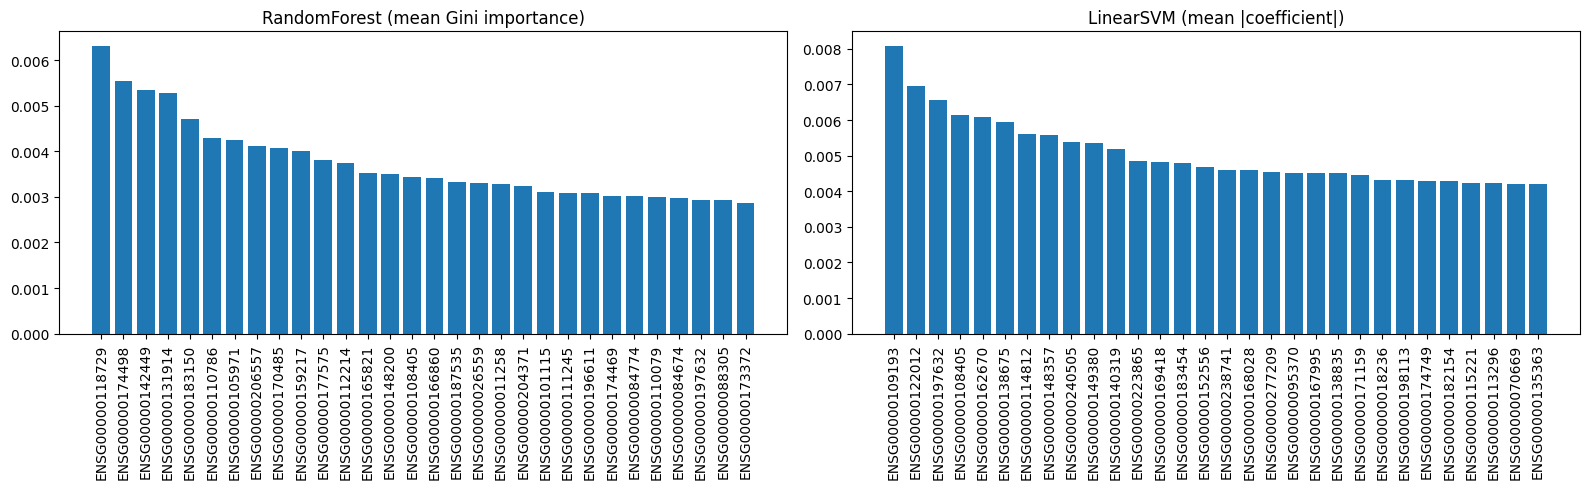

In [10]:
# ===== Cell 6: feature importance — RF (Gini) vs. LinearSVM (|coef|) =====
rf_imp_df = (
    pd.DataFrame({"gene": GENE_COLS, "importance": rf_importances.mean(axis=0)})
    .sort_values("importance", ascending=False).reset_index(drop=True)
)
svm_imp_df = (
    pd.DataFrame({"gene": GENE_COLS, "importance": svm_coef_abs.mean(axis=0)})
    .sort_values("importance", ascending=False).reset_index(drop=True)
)

def report_concentration(df, name):
    total = df["importance"].sum()
    top1  = df["importance"].iloc[0]  / total
    top5  = df["importance"].iloc[:5].sum()  / total
    top20 = df["importance"].iloc[:20].sum() / total
    print(f"{name}: top1={top1:.1%} | top5={top5:.1%} | top20={top20:.1%} (of {len(df)} genes)")
    print(df.head(10))
    print()

report_concentration(rf_imp_df, "RandomForest")
report_concentration(svm_imp_df, "LinearSVM")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(range(30), rf_imp_df["importance"].iloc[:30])
axes[0].set_xticks(range(30)); axes[0].set_xticklabels(rf_imp_df["gene"].iloc[:30], rotation=90)
axes[0].set_title("RandomForest (mean Gini importance)")

axes[1].bar(range(30), svm_imp_df["importance"].iloc[:30])
axes[1].set_xticks(range(30)); axes[1].set_xticklabels(svm_imp_df["gene"].iloc[:30], rotation=90)
axes[1].set_title("LinearSVM (mean |coefficient|)")

plt.tight_layout()
plt.show()